In [1]:
# 犬と猫の画像400枚（それぞれ200枚ずつ）をデータセットとしてプログラムに取り込み、深層学習を行なってください。
# Flickr のサイトから入手した著作権フリーの犬と猫の写真（すべて画像サイズは75×75）です。
# train の写真は150枚ずつ、また test の写真は50枚ずつ用意しています。

import tensorflow as tf

train_dataset = tf.keras.preprocessing.image_dataset_from_directory(
    "dog_cat_photos/train", 
    image_size=(224, 224), 
    label_mode="binary", 
    batch_size=32, 
    shuffle=True
)

test_dataset = tf.keras.preprocessing.image_dataset_from_directory(
    "dog_cat_photos/test", 
    image_size=(224, 224), 
    label_mode="binary", 
    batch_size=32, 
    shuffle=False
)

Found 300 files belonging to 2 classes.
Found 100 files belonging to 2 classes.


In [4]:
list(train_dataset.as_numpy_iterator())[0]

(array([[[[1.20000000e+01, 1.10000000e+01, 1.70000000e+01],
          [1.19955359e+01, 1.09955359e+01, 1.69933033e+01],
          [1.13258924e+01, 1.03258924e+01, 1.59888391e+01],
          ...,
          [1.73370514e+01, 1.13370514e+01, 1.20111542e+01],
          [1.70022278e+01, 1.10022278e+01, 1.10066833e+01],
          [1.70000000e+01, 1.10000000e+01, 1.10000000e+01]],
 
         [[1.19843750e+01, 1.09843750e+01, 1.69843750e+01],
          [1.19799404e+01, 1.09799404e+01, 1.69777126e+01],
          [1.13147812e+01, 1.03147812e+01, 1.59784803e+01],
          ...,
          [1.73303547e+01, 1.13303547e+01, 1.20044575e+01],
          [1.69955311e+01, 1.09955311e+01, 1.09999866e+01],
          [1.69933033e+01, 1.09933033e+01, 1.09933033e+01]],
 
         [[9.64062500e+00, 8.64062500e+00, 1.46406250e+01],
          [9.64067459e+00, 8.64067459e+00, 1.46391945e+01],
          [9.64814758e+00, 8.64814758e+00, 1.44246998e+01],
          ...,
          [1.63258896e+01, 1.03258905e+01, 1.0999

In [5]:
class_names = train_dataset.class_names
class_names

['cat', 'dog']

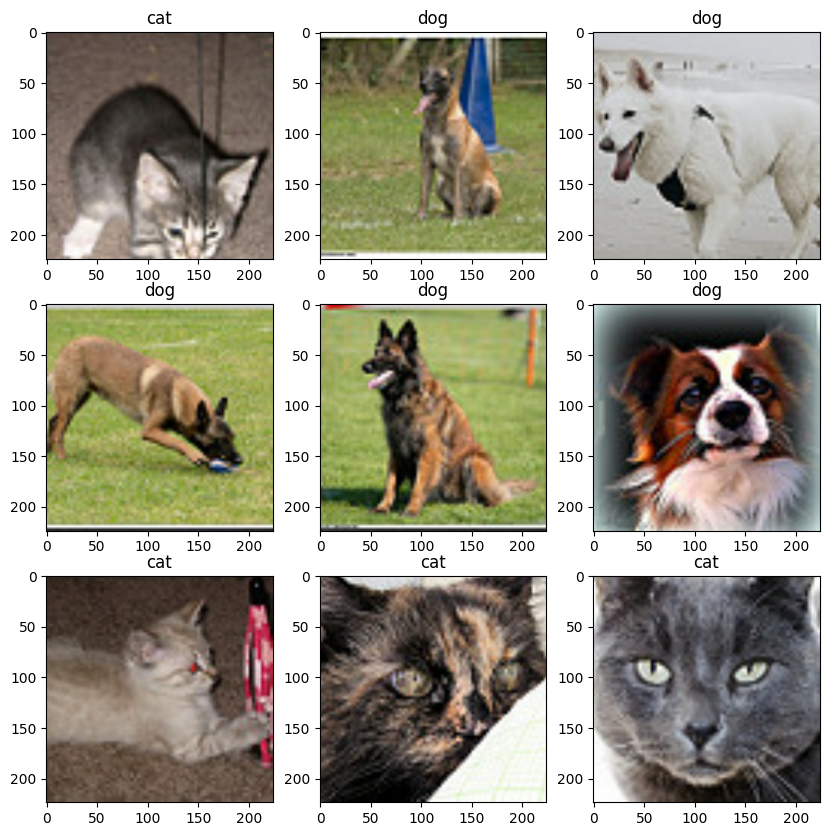

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 10))

for images, labels in train_dataset.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i].numpy().astype("uint8")[0]])


In [15]:
def flip_left_right(image, label):
    image = tf.image.flip_left_right(image)
    return image, label

def flip_up_down(image, label):
    image = tf.image.flip_up_down(image)
    return image, label

def rot90(image, label):
    image = tf.image.rot90(image)
    return image, label

def rot180(image, label):
    image = tf.image.rot90(image, k=2)
    return image, label

def rot270(image, label):
    image = tf.image.rot90(image, k=3)
    return image, label

In [16]:
train_dataset_lr = train_dataset.map(flip_left_right)
train_dataset_ud = train_dataset.map(flip_up_down)
train_dataset_rot90 = train_dataset.map(rot90)
train_dataset_rot180 = train_dataset.map(rot180)
train_dataset_rot270 = train_dataset.map(rot270)

In [17]:
train_dataset = train_dataset.concatenate(train_dataset_lr)
train_dataset = train_dataset.concatenate(train_dataset_ud)
train_dataset = train_dataset.concatenate(train_dataset_rot90)
train_dataset = train_dataset.concatenate(train_dataset_rot180)
train_dataset = train_dataset.concatenate(train_dataset_rot270)

In [19]:
train_dataset = train_dataset.shuffle(32)

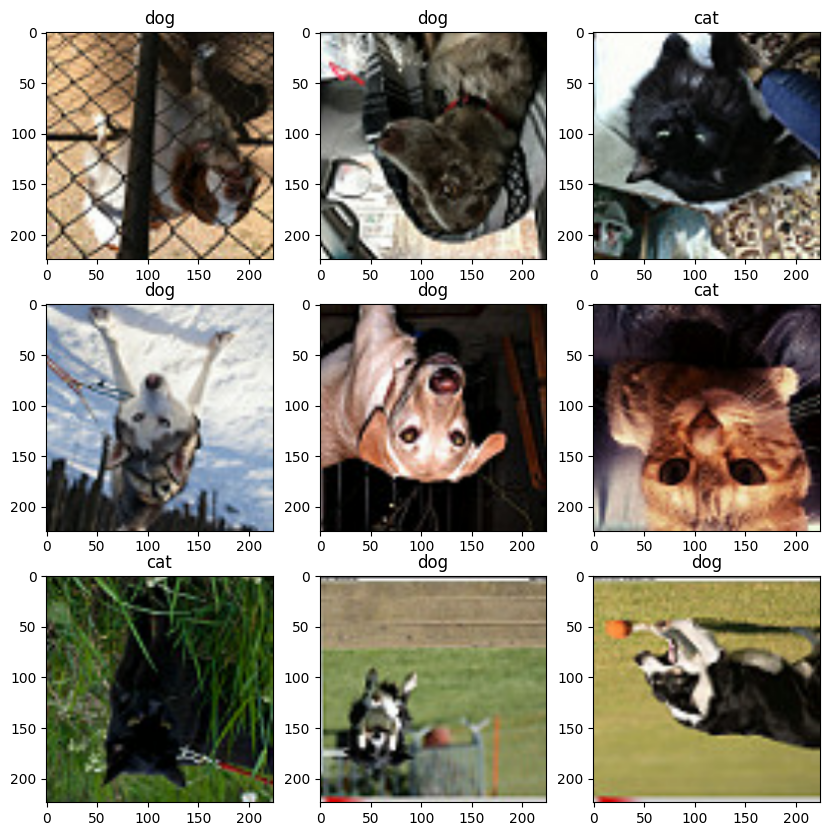

In [20]:
plt.figure(figsize=(10, 10))

for images, labels in train_dataset.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i].numpy().astype("uint8")[0]])

In [23]:
input_layer = tf.keras.Input(shape=(224, 224, 3))
l_layer = tf.keras.applications.mobilenet_v2.preprocess_input(input_layer)

base_model = tf.keras.applications.mobilenet_v2.MobileNetV2(
    input_shape=(224, 224, 3), 
    input_tensor=l_layer, 
    include_top=False, 
    weights="imagenet", 
    pooling='avg'
)
base_model.trainable = False

In [24]:
output_layer = tf.keras.layers.Dense(1, activation='sigmoid')

In [25]:
model = tf.keras.Sequential([
    base_model, output_layer
])

In [26]:
model.compile(optimizer="adam", 
              loss='binary_crossentropy', 
              metrics=["accuracy"])

In [27]:
model.fit(train_dataset, epochs=20)

Epoch 1/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 22s 311ms/step - accuracy: 0.8344 - loss: 0.3704
Epoch 2/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 22s 352ms/step - accuracy: 0.9256 - loss: 0.1997
Epoch 3/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 23s 359ms/step - accuracy: 0.9428 - loss: 0.1547
Epoch 4/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 22s 342ms/step - accuracy: 0.9628 - loss: 0.1259
Epoch 5/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 26s 426ms/step - accuracy: 0.9667 - loss: 0.1090
Epoch 6/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 30s 460ms/step - accuracy: 0.9772 - loss: 0.0921
Epoch 7/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 25s 393ms/step - accuracy: 0.9800 - loss: 0.0815
Epoch 8/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 24s 388ms/step - accuracy: 0.9822 - loss: 0.0714
Epoch 9/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 23s 374ms/step - accuracy: 0.9794 - loss: 0.0712
Epoch 10/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 24s 378ms/step - accuracy: 0.9900 - loss: 0.0579
Epoch 11/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 23s 363ms/step - accuracy: 0.9889 - loss: 0.0524
Epoch 12/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 23

In [30]:
pred_data = model.predict(test_dataset)

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 188ms/step


In [31]:
pred_data

array([[7.19054369e-05],
       [3.46345041e-04],
       [2.02589763e-05],
       [1.30034075e-03],
       [5.01895498e-04],
       [4.00704244e-04],
       [6.72536495e-04],
       [3.66242573e-04],
       [1.44522273e-05],
       [5.73076133e-04],
       [3.70332564e-05],
       [8.75237584e-03],
       [7.79270474e-03],
       [5.31206548e-04],
       [1.00100166e-04],
       [7.15775377e-06],
       [5.35737745e-05],
       [3.75889329e-04],
       [3.23629519e-03],
       [2.33508577e-03],
       [1.25039807e-02],
       [6.82111159e-02],
       [2.20139162e-03],
       [2.67340569e-03],
       [2.09442779e-01],
       [1.72220054e-03],
       [8.17865832e-04],
       [5.46086405e-04],
       [6.49274932e-03],
       [1.73338398e-04],
       [1.08361954e-03],
       [8.02022219e-01],
       [1.11686089e-03],
       [1.21041259e-03],
       [2.82611838e-03],
       [8.89001191e-01],
       [4.72726719e-03],
       [1.54224038e-03],
       [2.66636852e-02],
       [4.40319709e-04],


In [32]:
model.evaluate(test_dataset)

4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 196ms/step - accuracy: 0.9600 - loss: 0.0689


[0.06886884570121765, 0.9599999785423279]